In [1]:
import numpy as np
from classy import Class
import matplotlib.pyplot as plt

k_s = 0.5
z_s = 0.0

l_max_CMB = 2500
l_max_LSS = 200

MyUniverse = Class()
MyUniverse.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
MyUniverse.set({'output':'tCl,pCl,aCl,nCl,lCl,mPk,mTk',
               'k_output_values':k_s, 
               'gauge':'newton',
               'birefringence':'yes','Axion_field':'yes',
               'axf_parameters':'8e-27,0.53,0.0',
               'axf_g':'2.436e3',
               'lensing':'yes','P_k_max_1/Mpc':3.0})
MyUniverse.compute()

In [2]:
back_MyUniverse = MyUniverse.get_background()
ther_MyUniverse = MyUniverse.get_thermodynamics()
perT_MyUniverse = MyUniverse.get_perturbations()
perK_MyUniverse = MyUniverse.get_transfer()
prim_MyUniverse = MyUniverse.get_primordial()
CMBR_MyUniverse = MyUniverse.raw_cl(l_max_CMB)
LSSU_MyUniverse = MyUniverse.density_cl(l_max_LSS)

print("BACKGROUND QUANTITIES")
for key in back_MyUniverse.keys():
    print(key)
print("\n")

print("THERMODYNAMICS QUANTITIES")
for key in ther_MyUniverse.keys():
    print(key)
print("\n")

print('SCALAR PERTURBATION QUANTITIES VS TIME AT k = '+str(k_s) + '/Mpc')
for header in perT_MyUniverse['scalar'][0]:
    print(header)
print("\n")

print('SCALAR PERTURBATION QUANTITIES VS WAVE NUMBER AT z = '+ str(z_s))
for key in perK_MyUniverse.keys():
    print(key)
print("\n")

print('PRIMORDIAL QUANTITIES VS WAVE NUMBER')
for key in prim_MyUniverse.keys():
    print(key)
print("\n")

print("HARMONIC CMB QUANTITIES")
for key in CMBR_MyUniverse.keys():
    print(key)
print("\n")
    
print("HARMONIC LSS QUANTITIES")
for key in LSSU_MyUniverse.keys():
    print(key)
print("\n")

BACKGROUND QUANTITIES
z
proper time [Gyr]
conf. time [Mpc]
H [1/Mpc]
comov. dist.
ang.diam.dist.
lum. dist.
comov.snd.hrz.
(.)rho_g
(.)rho_b
(.)rho_cdm
(.)rho_lambda
(.)rho_ur
(.)rho_crit
(.)rho_axf
(.)p_axf
(.)p_prime_axf
chi_axf
chi'_axf
V_axf
V'_axf
V''_axf
w_axf
beta_axf
(.)rho_tot
(.)p_tot
(.)p_tot_prime
gr.fac. D
gr.fac. f


THERMODYNAMICS QUANTITIES
scale factor a
z
conf. time [Mpc]
x_e
kappa' [Mpc^-1]
exp(-kappa)
g [Mpc^-1]
Tb [K]
dTb [K]
w_b
c_b^2
tau_d


SCALAR PERTURBATION QUANTITIES VS TIME AT k = 0.5/Mpc
tau [Mpc]
a
delta_g
theta_g
shear_g
pol0_g
pol1_g
pol2_g
delta_b
theta_b
psi
phi
delta_ur
theta_ur
shear_ur
delta_cdm
theta_cdm
delta_chi_axf


SCALAR PERTURBATION QUANTITIES VS WAVE NUMBER AT z = 0.0
k (h/Mpc)
d_g
d_b
d_cdm
d_ur
d_m
d_tot
phi
psi
delta_chi_axf


PRIMORDIAL QUANTITIES VS WAVE NUMBER
k [1/Mpc]
P_scalar(k)


HARMONIC CMB QUANTITIES
tt
ee
te
bb
tb
eb
aa
at
ae
ap
pp
tp
ell


HARMONIC LSS QUANTITIES
dd
ad
ell




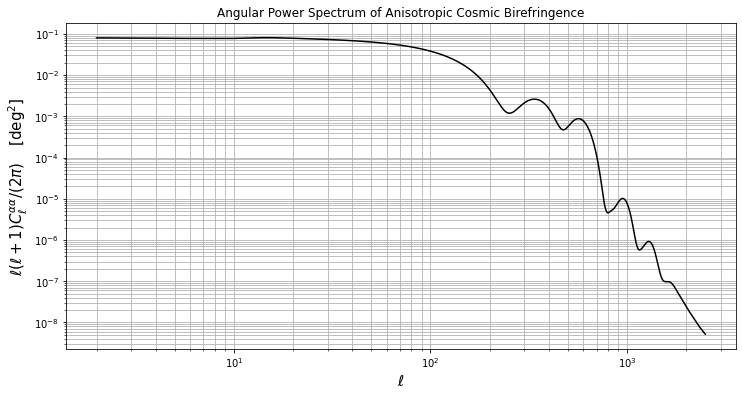

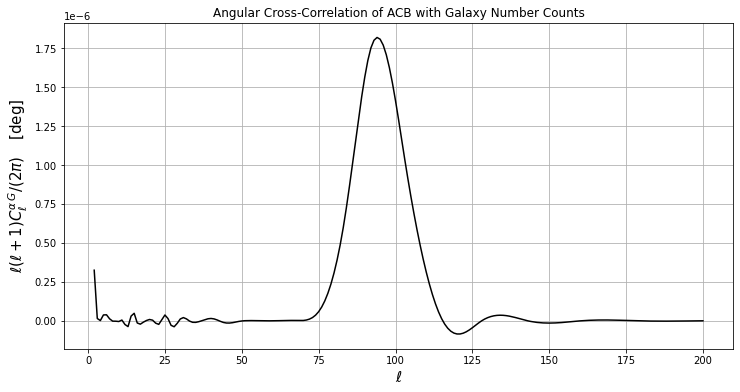

In [3]:
ClAA = CMBR_MyUniverse['aa'][2:]
ll   = CMBR_MyUniverse['ell'][2:]

plt.figure(figsize=(12,6))
plt.title("Angular Power Spectrum of Anisotropic Cosmic Birefringence")
plt.loglog(ll,ll*(ll+1)*ClAA/2/np.pi*(180/np.pi)**2,color='black')
plt.xlabel(r'$\ell$',size=15)
plt.ylabel(r'$\ell(\ell+1)C_{\ell}^{\alpha\alpha}/(2\pi)\,\,\,\,\,\,\,$[deg$^2$]',size=15)
plt.grid(True, which="both", ls="-")
plt.show()

ClAG = LSSU_MyUniverse['ad'][2:]
ll   = LSSU_MyUniverse['ell'][2:]

plt.figure(figsize=(12,6))
plt.title("Angular Cross-Correlation of ACB with Galaxy Number Counts")
plt.plot(ll,ll*(ll+1)*ClAG/2/np.pi*(180/np.pi),color='black')
plt.xlabel(r'$\ell$',size=15)
plt.ylabel(r'$\ell(\ell+1)C_{\ell}^{\alpha\,G}/(2\pi)\,\,\,\,\,\,\,$[deg]',size=15)
plt.grid(True)
plt.show()

In [10]:
print(MyUniverse.get_current_derived_parameters(['z_rec']))

print(MyUniverse.get_current_derived_parameters(['conformal_age']))

{'z_rec': 1088.7752465966093}
{'conformal_age': 14151.897989905854}
